In [2]:
!pip install mplfinance

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import yfinance as yf
import psycopg2
import warnings

warnings.filterwarnings('ignore')

# ตั้งค่าฟอนต์ภาษาไทยสำหรับ Matplotlib
plt.rcParams['font.family'] = 'Tahoma' 

# 🔌 เชื่อมต่อ Database (รันครั้งเดียวใช้ได้ตลอดยาวๆ)
conn = psycopg2.connect(
    host="127.0.0.1", 
    database="set_quant", 
    user="postgres", 
    password="Shifa.326459"
)
print("✅ Database Connected Successfully!")

✅ Database Connected Successfully!


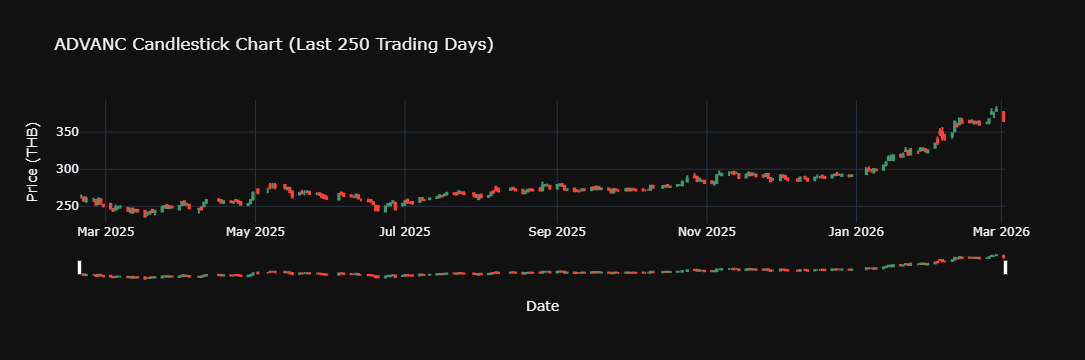

In [14]:
stock_symbol = 'ADVANC'

# ดึงข้อมูลราคาหุ้นจาก Database
query_price = f"""
    SELECT date, open, high, low, close 
    FROM fact_daily_prices 
    WHERE symbol = '{stock_symbol}' 
    ORDER BY date DESC 
    LIMIT 250
"""
df_stock = pd.read_sql(query_price, conn)
df_stock = df_stock.sort_values('date').reset_index(drop=True) # เรียงวันที่จากอดีตมาปัจจุบัน

# สร้างกราฟแท่งเทียน
fig_stock = go.Figure(data=[go.Candlestick(
    x=df_stock['date'],
    open=df_stock['open'],
    high=df_stock['high'],
    low=df_stock['low'],
    close=df_stock['close'],
    name=stock_symbol
)])

fig_stock.update_layout(
    title=f'{stock_symbol} Candlestick Chart (Last 250 Trading Days)',
    yaxis_title='Price (THB)',
    xaxis_title='Date',
    template='plotly_dark' # เปลี่ยนธีมให้ดูเป็น Quant มากขึ้น
)
fig_stock.show()